## What is the most optimal skill to learn for Data Analysts?

### Methodology

 1. Group skills to determine median salary and likelihood of being in positng
 2. Visualize median salary vs percent skill demand 
 3. (Optional) Determine if certain technology are more prevalent

In [1]:
## importing libraries 
import ast
import pandas as pd
import seaborn as sns 
from datasets import load_dataset
import matplotlib.pyplot as plt 

## loading data 
dataset= load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

## data cleaning 
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\mahar\anaconda3\envs\python_youtube\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_Da_US= df[(df['job_country']=='United States') & (df['job_title_short']=='Data Analyst') ].copy()


In [3]:
df_Da_US = df_Da_US.dropna(subset=['salary_year_avg'])

df_Da_US_exploded = df_Da_US.explode('job_skills')


In [4]:
df_da_skill=df_Da_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count', ascending=False)

df_da_skill = df_da_skill.rename(columns={'count':'skill_count', 'median':'salary_median'})

In [5]:
DA_job_count = len(df_Da_US)

df_da_skill['Skill_percentage'] = (df_da_skill['skill_count'] / DA_job_count) * 100

df_da_skill.head(10)

,skill_count,salary_median,Skill_percentage
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


In [6]:
skill_percentage = 5

df_da_skill_optimal = df_da_skill[df_da_skill['Skill_percentage'] > skill_percentage]

df_da_skill_optimal

,skill_count,salary_median,Skill_percentage
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


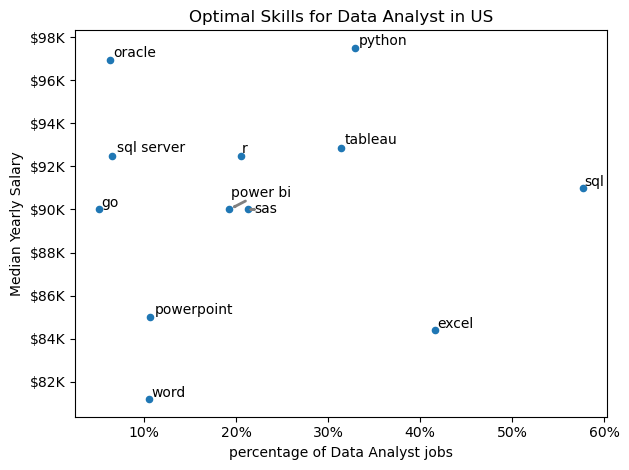

In [ ]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

## scatter plot 
df_da_skill_optimal.plot(kind='scatter',x='Skill_percentage',y='salary_median')

## adding text annotations 
texts=[]
for i , txt in enumerate(df_da_skill_optimal.index):
 texts.append(plt.text(df_da_skill_optimal['Skill_percentage'].iloc[i],df_da_skill_optimal['salary_median'].iloc[i],txt))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='grey',lw=2))

## formatting the y axis for salary in 100k format 
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y , pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))


## set  axis labels and title 
plt.xlabel('percentage of Data Analyst jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Optimal Skills for Data Analyst in US')

## adjust layout and display the plot 
plt.tight_layout()
plt.show()